# Exercise 2: Denoising Diffusion Probabilistic Models (DDPMs)

**Advanced Deep Learning — Winter 2025/2026**

---

In this exercise we implement a **Denoising Diffusion Probabilistic Model (DDPM)** from scratch and train it on CIFAR-10. By the end of this notebook you will have:

1. Understood the forward (noising) and reverse (denoising) diffusion process mathematically.
2. Implemented three different **beta/variance schedules** (linear, cosine, sigmoid).
3. Built the full training pipeline with an **Attention-UNet** backbone.
4. Extended the model with **Classifier-Free Guidance (CFG)** for class-conditional generation.

### References
- Ho et al. (2020): [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239)
- Nichol & Dhariwal (2021): [Improved Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2102.09672)
- Ho & Salimans (2022): [Classifier-Free Diffusion Guidance](https://arxiv.org/abs/2207.12598)

---

## Table of Contents

1. [Setup & Imports](#1-setup--imports)
2. [Exercise 2.1 — Code Structure Overview](#2-exercise-21--code-structure-overview)
3. [Exercise 2.2 — The Forward Diffusion Process](#3-exercise-22--the-forward-diffusion-process)
4. [Exercise 2.2 — The Reverse (Denoising) Process & Loss](#4-exercise-22--the-reverse-denoising-process--loss)
5. [Exercise 2.3 — Beta Schedulers](#5-exercise-23--beta-schedulers)
6. [Exercise 2.4 — Classifier-Free Guidance](#6-exercise-24--classifier-free-guidance)
7. [Training Loop](#7-training-loop)
8. [Visualization & Results](#8-visualization--results)

---
## 1. Setup & Imports

In [1]:
import torch
import torchvision
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torchvision.transforms import Compose, ToTensor, Lambda, ToPILImage, CenterCrop, Resize
from torchvision import datasets, transforms
from PIL import Image
from tqdm.auto import tqdm
import numpy as np
from pathlib import Path
import os
import math
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display

# Check GPU availability
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

c:\Users\z0054n2m\AppData\Local\miniforge3\envs\ai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
GPU: NVIDIA RTX 2000 Ada Generation Laptop GPU


In [2]:
# CIFAR-10 class names
CIFAR10_CLASSES = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

---
## 2. Exercise 2.1 — Code Structure Overview

Before we dive into the math and implementation, let's understand the overall architecture.

The codebase consists of four main modules:

| File | Purpose |
|------|---------|
| `ex02_model.py` | Attention-UNet backbone (the noise predictor $\epsilon_\theta$) |
| `ex02_diffusion.py` | `Diffusion` class — forward/reverse process, loss |
| `ex02_helpers.py` | Utility functions (`extract`, `Residual`, etc.) |
| `ex02_main.py` | Dataset loading, training loop, visualizations |

### The Big Picture

```
  Clean Image x_0  ──[Forward q]──►  Noisy x_t  ──[Reverse p_θ]──►  Reconstructed x_0
                        (fixed)                     (learned UNet)
```

The UNet takes a **noisy image** $x_t$ and a **timestep** $t$ (encoded as sinusoidal positional embeddings), and predicts the **noise** $\epsilon$ that was added. Training simply minimizes the distance between the predicted and true noise.

### UNet Architecture

The backbone follows a standard encoder–bottleneck–decoder structure with skip connections:
- **Encoder**: ResNet blocks + linear attention + downsampling
- **Bottleneck**: ResNet blocks + full self-attention
- **Decoder**: ResNet blocks + linear attention + upsampling + skip connections

Conditioning on time (and later on class label) is injected via **FiLM** (Feature-wise Linear Modulation) in every ResNet block.

In [3]:
# ── Paste or import model code ──────────────────────────────────────────────
# If running from the same directory as the source files:
# from ex02_model import Unet
# from ex02_helpers import extract

# Otherwise, paste the contents of ex02_helpers.py and ex02_model.py here.
# For this notebook we inline the helpers so it is self-contained.

# --- ex02_helpers.py (inline) ------------------------------------------------
from torch import nn
from inspect import isfunction
from einops import rearrange, reduce
from einops.layers.torch import Rearrange
from functools import partial
from torch import einsum

def exists(x):
    return x is not None

def default(val, d):
    if exists(val):
        return val
    return d() if isfunction(d) else d

def num_to_groups(num, divisor):
    groups = num // divisor
    remainder = num % divisor
    arr = [divisor] * groups
    if remainder > 0:
        arr.append(remainder)
    return arr

class Residual(nn.Module):
    def __init__(self, fn):
        super().__init__()
        self.fn = fn
    def forward(self, x, *args, **kwargs):
        return self.fn(x, *args, **kwargs) + x

def Upsample(dim, dim_out=None):
    return nn.Sequential(
        nn.Upsample(scale_factor=2, mode="nearest"),
        nn.Conv2d(dim, default(dim_out, dim), 3, padding=1),
    )

def Downsample(dim, dim_out=None):
    return nn.Sequential(
        Rearrange("b c (h p1) (w p2) -> b (c p1 p2) h w", p1=2, p2=2),
        nn.Conv2d(dim * 4, default(dim_out, dim), 1),
    )

def extract(a, t, x_shape):
    """Gather values from tensor `a` at indices `t`, then reshape to broadcast over x."""
    batch_size = t.shape[0]
    out = a.gather(-1, t.cpu())
    return out.reshape(batch_size, *((1,) * (len(x_shape) - 1))).to(t.device)

print("Helper utilities loaded.")

Helper utilities loaded.


In [4]:
# --- ex02_model.py (inline) --------------------------------------------------

class SinusoidalPositionEmbeddings(nn.Module):
    """
    Encodes the scalar timestep t as a high-dimensional vector using sinusoidal
    functions — identical in spirit to Transformer positional encodings.

    PE_{t,2i}   = sin(t / 10000^(2i/d))
    PE_{t,2i+1} = cos(t / 10000^(2i/d))
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class WeightStandardizedConv2d(nn.Conv2d):
    """Conv2d with weight standardization for better training with GroupNorm."""
    def forward(self, x):
        eps = 1e-5 if x.dtype == torch.float32 else 1e-3
        weight = self.weight
        mean = reduce(weight, "o ... -> o 1 1 1", "mean")
        var  = reduce(weight, "o ... -> o 1 1 1", partial(torch.var, unbiased=False))
        normalized_weight = (weight - mean) * (var + eps).rsqrt()
        return F.conv2d(x, normalized_weight, self.bias, self.stride,
                        self.padding, self.dilation, self.groups)


class Block(nn.Module):
    """Basic building block: WS-Conv → GroupNorm → FiLM conditioning → SiLU."""
    def __init__(self, dim, dim_out, groups=8):
        super().__init__()
        self.proj = WeightStandardizedConv2d(dim, dim_out, 3, padding=1)
        self.norm = nn.GroupNorm(groups, dim_out)
        self.act  = nn.SiLU()

    def forward(self, x, scale_shift=None):
        x = self.proj(x)
        x = self.norm(x)
        if exists(scale_shift):
            scale, shift = scale_shift
            x = x * (scale + 1) + shift   # FiLM: feature-wise linear modulation
        return self.act(x)


class ResnetBlock(nn.Module):
    """ResNet block conditioned on time (and optionally class) embeddings via FiLM."""
    def __init__(self, dim, dim_out, *, time_emb_dim=None, classes_emb_dim=None, groups=8):
        super().__init__()
        full_emb_dim = int(default(time_emb_dim, 0)) + int(default(classes_emb_dim, 0))
        self.mlp = nn.Sequential(nn.SiLU(), nn.Linear(full_emb_dim, dim_out * 2)) \
                   if exists(time_emb_dim) or exists(classes_emb_dim) else None
        self.block1   = Block(dim, dim_out, groups=groups)
        self.block2   = Block(dim_out, dim_out, groups=groups)
        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()

    def forward(self, x, time_emb=None, class_emb=None):
        scale_shift = None
        if exists(self.mlp) and (exists(time_emb) or exists(class_emb)):
            cond_emb = tuple(filter(exists, (time_emb, class_emb)))
            cond_emb = torch.cat(cond_emb, dim=-1)
            cond_emb = self.mlp(cond_emb)
            cond_emb = rearrange(cond_emb, 'b c -> b c 1 1')
            scale_shift = cond_emb.chunk(2, dim=1)
        h = self.block1(x, scale_shift=scale_shift)
        h = self.block2(h)
        return h + self.res_conv(x)


class Attention(nn.Module):
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head ** -0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out  = nn.Conv2d(hidden_dim, dim, 1)

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv)
        q = q * self.scale
        sim = einsum("b h d i, b h d j -> b h i j", q, k)
        sim = sim - sim.amax(dim=-1, keepdim=True).detach()
        attn = sim.softmax(dim=-1)
        out  = einsum("b h i j, b h d j -> b h i d", attn, v)
        out  = rearrange(out, "b h (x y) d -> b (h d) x y", x=h, y=w)
        return self.to_out(out)


class LinearAttention(nn.Module):
    """Linear attention — O(n) complexity, used in the encoder/decoder."""
    def __init__(self, dim, heads=4, dim_head=32):
        super().__init__()
        self.scale = dim_head ** -0.5
        self.heads = heads
        hidden_dim = dim_head * heads
        self.to_qkv = nn.Conv2d(dim, hidden_dim * 3, 1, bias=False)
        self.to_out  = nn.Sequential(nn.Conv2d(hidden_dim, dim, 1), nn.GroupNorm(1, dim))

    def forward(self, x):
        b, c, h, w = x.shape
        qkv = self.to_qkv(x).chunk(3, dim=1)
        q, k, v = map(lambda t: rearrange(t, "b (h c) x y -> b h c (x y)", h=self.heads), qkv)
        q = q.softmax(dim=-2)
        k = k.softmax(dim=-1)
        q = q * self.scale
        context = torch.einsum("b h d n, b h e n -> b h d e", k, v)
        out = torch.einsum("b h d e, b h d n -> b h e n", context, q)
        out = rearrange(out, "b h c (x y) -> b (h c) x y", h=self.heads, x=h, y=w)
        return self.to_out(out)


class PreNorm(nn.Module):
    def __init__(self, dim, fn):
        super().__init__()
        self.fn   = fn
        self.norm = nn.GroupNorm(1, dim)
    def forward(self, x):
        return self.fn(self.norm(x))


class Unet(nn.Module):
    """
    Attention-UNet noise predictor ε_θ(x_t, t, [c]).
    Supports optional class conditioning via an embedding layer + FiLM.
    """
    def __init__(self, dim, init_dim=None, out_dim=None,
                 dim_mults=(1,2,4,8), channels=3, resnet_block_groups=4,
                 class_free_guidance=False, p_uncond=None, num_classes=None):
        super().__init__()
        self.channels = channels
        init_dim = default(init_dim, dim)
        self.init_conv = nn.Conv2d(channels, init_dim, 1, padding=0)
        dims   = [init_dim, *map(lambda m: dim * m, dim_mults)]
        in_out = list(zip(dims[:-1], dims[1:]))
        block_klass = partial(ResnetBlock, groups=resnet_block_groups)

        # Time embedding: scalar t → high-dim vector
        time_dim = dim * 4
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(dim),
            nn.Linear(dim, time_dim), nn.GELU(), nn.Linear(time_dim, time_dim)
        )

        # Class embedding (optional)
        self.num_classes = num_classes
        classes_dim = 0
        if num_classes is not None:
            # +1 for the null token used in unconditional generation
            self.classes_emb = nn.Embedding(num_classes + 1, time_dim)
            classes_dim = time_dim
        else:
            self.classes_emb = None

        num_resolutions = len(in_out)
        # Encoder
        self.downs = nn.ModuleList([])
        for ind, (dim_in, dim_out) in enumerate(in_out):
            is_last = ind >= (num_resolutions - 1)
            self.downs.append(nn.ModuleList([
                block_klass(dim_in, dim_in, time_emb_dim=time_dim, classes_emb_dim=classes_dim),
                block_klass(dim_in, dim_in, time_emb_dim=time_dim, classes_emb_dim=classes_dim),
                Residual(PreNorm(dim_in, LinearAttention(dim_in))),
                Downsample(dim_in, dim_out) if not is_last else nn.Conv2d(dim_in, dim_out, 3, padding=1),
            ]))

        # Bottleneck
        mid_dim = dims[-1]
        self.mid_block1 = block_klass(mid_dim, mid_dim, time_emb_dim=time_dim, classes_emb_dim=classes_dim)
        self.mid_attn   = Residual(PreNorm(mid_dim, Attention(mid_dim)))
        self.mid_block2 = block_klass(mid_dim, mid_dim, time_emb_dim=time_dim, classes_emb_dim=classes_dim)

        # Decoder
        self.ups = nn.ModuleList([])
        for ind, (dim_in, dim_out) in enumerate(reversed(in_out)):
            is_last = ind == (len(in_out) - 1)
            self.ups.append(nn.ModuleList([
                block_klass(dim_out + dim_in, dim_out, time_emb_dim=time_dim, classes_emb_dim=classes_dim),
                block_klass(dim_out + dim_in, dim_out, time_emb_dim=time_dim, classes_emb_dim=classes_dim),
                Residual(PreNorm(dim_out, LinearAttention(dim_out))),
                Upsample(dim_out, dim_in) if not is_last else nn.Conv2d(dim_out, dim_in, 3, padding=1),
            ]))

        self.out_dim = default(out_dim, channels)
        self.final_res_block = block_klass(dim * 2, dim, time_emb_dim=time_dim, classes_emb_dim=classes_dim)
        self.final_conv = nn.Conv2d(dim, self.out_dim, 1)

    def forward(self, x, time, classes=None, cond_drop_prob=None):
        x = self.init_conv(x)
        r = x.clone()
        t = self.time_mlp(time)

        # --- Class conditioning ---
        c = None
        if self.classes_emb is not None:
            if classes is None:
                # Unconditional: use null token
                classes = torch.full((x.shape[0],), self.num_classes, device=x.device, dtype=torch.long)
            if self.training and cond_drop_prob is not None and cond_drop_prob > 0:
                keep_mask = torch.rand((x.shape[0],), device=x.device) > cond_drop_prob
                null_tokens = torch.full_like(classes, self.num_classes)
                classes = torch.where(keep_mask, classes, null_tokens)
            c = self.classes_emb(classes)

        h = []
        for block1, block2, attn, downsample in self.downs:
            x = block1(x, time_emb=t, class_emb=c);  h.append(x)
            x = block2(x, time_emb=t, class_emb=c);  x = attn(x);  h.append(x)
            x = downsample(x)

        x = self.mid_block1(x, time_emb=t, class_emb=c)
        x = self.mid_attn(x)
        x = self.mid_block2(x, time_emb=t, class_emb=c)

        for block1, block2, attn, upsample in self.ups:
            x = torch.cat((x, h.pop()), dim=1)
            x = block1(x, time_emb=t, class_emb=c)
            x = torch.cat((x, h.pop()), dim=1)
            x = block2(x, time_emb=t, class_emb=c);  x = attn(x)
            x = upsample(x)

        x = torch.cat((x, r), dim=1)
        x = self.final_res_block(x, time_emb=t, class_emb=c)
        return self.final_conv(x)


print("UNet model defined.")

UNet model defined.



## 3. Exercise 2.2 — The Forward Diffusion Process
An intuition for the forward diffusion process is, that we gradually add noise to an image, until we end up with pure Gaussian noise.

<div align="center">

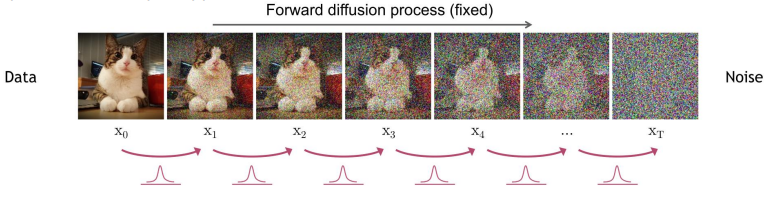

</div>

### 3.1 Mathematical Background

The **forward process** $q$ gradually adds Gaussian noise to a data sample $\mathbf{x}_0$ over $T$ timesteps:

$$q(\mathbf{x}_{1:T} | \mathbf{x}_0) := \prod_{t=1}^{T} q(\mathbf{x}_t | \mathbf{x}_{t-1})$$

Each step adds a small amount of noise controlled by the variance schedule $\beta_t \in (0, 1)$:

$$q(\mathbf{x}_t | \mathbf{x}_{t-1}) := \mathcal{N}(\mathbf{x}_t; \sqrt{1-\beta_t}\,\mathbf{x}_{t-1},\; \beta_t \mathbf{I})$$

#### The "Nice Property" — Closed-Form Sampling

By exploiting properties of the Gaussian distribution (merging $\mathcal{N}(0,\sigma_1^2 I)$ and $\mathcal{N}(0, \sigma_2^2 I)$ gives $\mathcal{N}(0,(\sigma_1^2+\sigma_2^2)I)$), we can skip straight to any arbitrary timestep $t$ from $\mathbf{x}_0$:

$$\boxed{\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t}\,\epsilon, \quad \epsilon \sim \mathcal{N}(\mathbf{0}, \mathbf{I})}$$

where $\alpha_t := 1 - \beta_t$ and $\bar{\alpha}_t := \prod_{s=1}^{t} \alpha_s$.

This is crucial for training: we can generate a training example at **any** noise level in a single step!

### 3.2 Implementation — `q_sample`

In [5]:
def q_sample(diffusor, x_zero, t, noise=None):
    """
    Forward diffusion: sample noisy image x_t from clean image x_0 at timestep t.
    
    Uses the closed-form (Eq. 4):
        x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * eps
    """
    if noise is None:
        noise = torch.randn_like(x_zero)
    
    sqrt_alphas_cumprod_t         = extract(diffusor.sqrt_alphas_cumprd, t, x_zero.shape)
    sqrt_one_minus_alphas_cumprod_t = extract(diffusor.sqrt_one_minus_alphas_cumprod, t, x_zero.shape)
    
    return sqrt_alphas_cumprod_t * x_zero + sqrt_one_minus_alphas_cumprod_t * noise


print("q_sample defined.")

q_sample defined.


### 3.3 Visualizing the Forward Process

Let's see what a CIFAR-10 image looks like as we progressively add noise:

Files already downloaded and verified


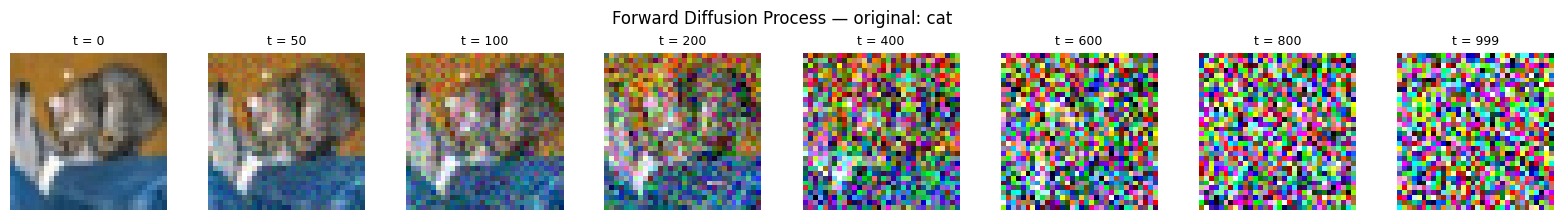

In [6]:
# We'll define a minimal Diffusion container so we can call q_sample
# (full Diffusion class is defined in Section 4)

def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, min=1e-5, max=0.02).to(torch.float32)


class MinimalDiffusor:
    """Minimal container for precomputed schedule values."""
    def __init__(self, timesteps, betas):
        self.betas = betas
        alphas = 1. - betas
        alphas_cumprod = torch.cumprod(alphas, dim=0)
        self.sqrt_alphas_cumprd = torch.sqrt(alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(torch.clamp(1. - alphas_cumprod, min=1e-6))


# Load a single CIFAR-10 image for illustration
transform_demo = Compose([transforms.ToTensor(), transforms.Lambda(lambda t: (t * 2) - 1)])
cifar_demo = datasets.CIFAR10('./data', download=True, train=False, transform=transform_demo)
sample_img, sample_label = cifar_demo[0]

timesteps_demo = 1000
betas_demo = cosine_beta_schedule(timesteps_demo)
diffusor_demo = MinimalDiffusor(timesteps_demo, betas_demo)

# Show the image at different noise levels
noise_levels = [0, 50, 100, 200, 400, 600, 800, 999]
fig, axes = plt.subplots(1, len(noise_levels), figsize=(16, 2.2))

for ax, t_val in zip(axes, noise_levels):
    t_tensor = torch.tensor([t_val])
    noisy = q_sample(diffusor_demo, sample_img.unsqueeze(0), t_tensor)[0]
    img_show = ((noisy.permute(1, 2, 0) + 1) / 2).clamp(0, 1).numpy()
    ax.imshow(img_show)
    ax.set_title(f"t = {t_val}", fontsize=9)
    ax.axis('off')

fig.suptitle(f'Forward Diffusion Process — original: {CIFAR10_CLASSES[sample_label]}', fontsize=12)
plt.tight_layout()
plt.show()


## 4. Exercise 2.2 — The Reverse (Denoising) Process & Loss
In the reverse process, we use a Neural Network to predict the noise, that was added to an image at a given timestp $t$.

<div align="center">

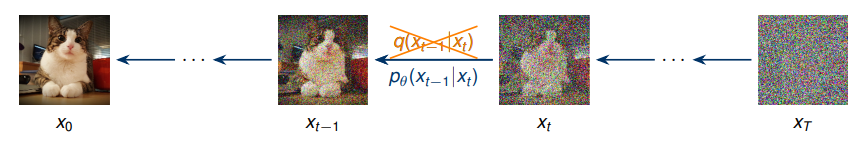

</div>

### 4.1 Mathematical Background

The **reverse process** $p_\theta$ learns to denoise step by step:

$$p_\theta(\mathbf{x}_{0:T}) := p(\mathbf{x}_T) \prod_{t=1}^{T} p_\theta(\mathbf{x}_{t-1} | \mathbf{x}_t)$$

We model each reverse step as a Gaussian with a **learned mean** and **fixed variance** $\sigma_t^2 = \beta_t$:

$$p_\theta(\mathbf{x}_{t-1} | \mathbf{x}_t) := \mathcal{N}(\mathbf{x}_{t-1};\; \mu_\theta(\mathbf{x}_t, t),\; \beta_t \mathbf{I})$$

Instead of predicting the mean directly, Ho et al. showed it is more effective to predict the **noise** $\epsilon$. The mean then follows as:

$$\mathbf{x}_{t-1} = \underbrace{\frac{1}{\sqrt{\alpha_t}}}_{\text{scale}} \left( \mathbf{x}_t - \underbrace{\frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}}}_{\text{noise coef}} \epsilon_\theta(\mathbf{x}_t, t) \right) + \underbrace{\sqrt{\beta_t}}_{\sigma_t} \mathbf{z}, \quad \mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$

> **Note:** The last stochastic term $\sqrt{\beta_t}\,\mathbf{z}$ is set to **zero** at $t = 0$ (the final denoising step).

### 4.2 Training Objective

The simplified loss is just the MSE between the true and predicted noise:

$$\mathcal{L}_{\text{simple}} = \mathbb{E}_{t, \mathbf{x}_0, \epsilon} \left[ \| \epsilon - \epsilon_\theta(\mathbf{x}_t, t) \|^2 \right]$$

### 4.3 Implementation — Full `Diffusion` Class

<div align="center">

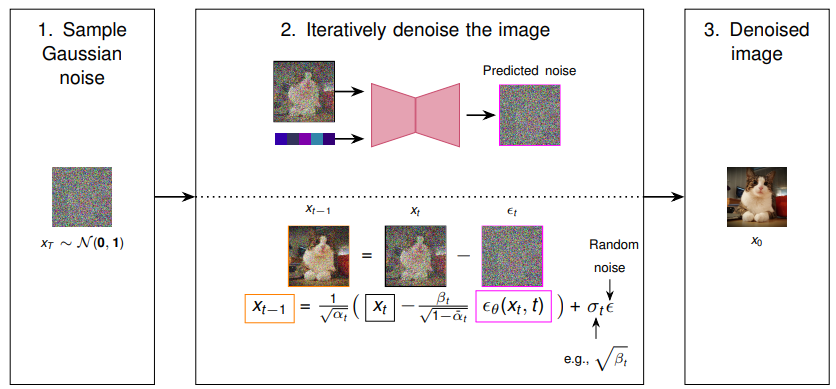

</div>

In [ ]:
def linear_beta_schedule(beta_start, beta_end, timesteps):
    """Linear schedule from Ho et al. (2020)."""
    return torch.linspace(beta_start, beta_end, timesteps)


def sigmoid_beta_schedule(beta_start, beta_end, timesteps):
    """
    Sigmoidal schedule (Exercise 2.3, Eq. 10):
        beta_t = beta_start + sigmoid(-s_limit + 2t/T * s_limit) * (beta_end - beta_start)
    """
    s_limit = 6.0
    t = torch.linspace(0, timesteps, timesteps)
    sigmoid_input = -s_limit + (2 * t / timesteps) * s_limit
    sigmoid_values = torch.sigmoid(sigmoid_input)
    return beta_start + sigmoid_values * (beta_end - beta_start)


class Diffusion:
    """
    Encapsulates the DDPM forward and reverse diffusion processes.
    
    Args:
        timesteps:          Number of diffusion steps T.
        get_noise_schedule: Callable returning a betas tensor of shape (T,).
        img_size:           Spatial size of the images.
        device:             PyTorch device string.
    """

    def __init__(self, timesteps, get_noise_schedule, img_size, device="cuda"):
        self.timesteps = timesteps
        self.img_size  = img_size
        self.device    = device

        # β schedule
        self.betas = get_noise_schedule(self.timesteps)

        # α_t = 1 - β_t
        self.alphas = 1. - self.betas
        # ᾱ_t = ∏_{s=1}^{t} α_s
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

        # Precomputed values used in the forward process (Eq. 4)
        self.sqrt_alphas_cumprd              = torch.sqrt(self.alphas_cumprod)
        self.sqrt_one_minus_alphas_cumprod   = torch.sqrt(torch.clamp(1. - self.alphas_cumprod, min=1e-6))

        # Precomputed values used in the reverse process (Eq. 8)
        self.sqrt_recip_alphas   = torch.sqrt(1.0 / self.alphas)       # 1/√α_t
        self.posterior_eps_coef  = self.betas / self.sqrt_one_minus_alphas_cumprod  # β_t / √(1 - ᾱ_t)
        self.sqrt_betas          = torch.sqrt(self.betas)               # σ_t = √β_t

    # ── Forward Process ────────────────────────────────────────────────────────

    def q_sample(self, x_zero, t, noise=None):
        """
        Forward diffusion: x_0 → x_t in one step (Eq. 4).
        
        x_t = √ᾱ_t · x_0 + √(1 − ᾱ_t) · ε
        """
        if noise is None:
            noise = torch.randn_like(x_zero)

        sqrt_ac_t  = extract(self.sqrt_alphas_cumprd, t, x_zero.shape)
        sqrt_omc_t = extract(self.sqrt_one_minus_alphas_cumprod, t, x_zero.shape)
        return sqrt_ac_t * x_zero + sqrt_omc_t * noise

    # ── Reverse Process ────────────────────────────────────────────────────────

    @torch.no_grad()
    def p_sample(self, model, x, t, t_index, classes=None, guidance_scale=0.0):
        """
        Single reverse step: x_t → x_{t-1}  (Eq. 8).
        
        Supports classifier-free guidance when `classes` and `guidance_scale` are given.
        """
        beta_t      = extract(self.betas, t, x.shape)
        sqrt_omc_t  = extract(self.sqrt_one_minus_alphas_cumprod, t, x.shape)
        sqrt_rec_t  = extract(self.sqrt_recip_alphas, t, x.shape)

        # Noise prediction (with optional CFG)
        if classes is not None and guidance_scale > 0.0:
            eps_cond   = model(x, t, classes=classes, cond_drop_prob=0.0)
            eps_uncond = model(x, t, classes=None,    cond_drop_prob=0.0)
            # CFG combination (Eq. 11): ẽ = (1+w)·ε_cond − w·ε_uncond
            predicted_noise = (1 + guidance_scale) * eps_cond - guidance_scale * eps_uncond
        else:
            predicted_noise = model(x, t)

        # Compute posterior mean μ_θ
        model_mean = sqrt_rec_t * (x - beta_t / sqrt_omc_t * predicted_noise)

        if t_index == 0:
            return model_mean  # No noise at the last step
        else:
            sigma_t = extract(self.sqrt_betas, t, x.shape)
            z = torch.randn_like(x)
            return model_mean + sigma_t * z

    @torch.no_grad()
    def sample(self, model, image_size, batch_size=16, channels=3,
               return_all_timesteps=False, classes=None, guidance_scale=0.0):
        """
        Full reverse diffusion: x_T ~ N(0,I)  →  x_0.
        Iterates p_sample from t=T down to t=0.
        """
        img = torch.randn((batch_size, channels, image_size, image_size), device=self.device)
        if classes is not None:
            classes = classes.to(self.device)

        imgs = [img]
        for i in tqdm(reversed(range(0, self.timesteps)), desc='Sampling', total=self.timesteps, leave=False):
            t   = torch.full((batch_size,), i, device=self.device, dtype=torch.long) # Tensor of shape (batch_size,) filled with the current timestep index
            img = self.p_sample(model, img, t, i, classes=classes, guidance_scale=guidance_scale)
            if return_all_timesteps:
                imgs.append(img)

        if return_all_timesteps:
            return torch.stack(imgs, dim=0)
        return torch.clamp(img, -1.0, 1.0)

    # ── Loss ───────────────────────────────────────────────────────────────────

    def p_losses(self, denoise_model, x_zero, t, noise=None, loss_type="l2",
                 classes=None, cond_drop_prob=None):
        """
        Compute the DDPM training loss L_simple.
        
        Steps:
          1. Sample (or use provided) noise ε.
          2. Apply forward process: x_t = q_sample(x_0, t, ε).
          3. Predict ε̂ = ε_θ(x_t, t).
          4. Return ||ε − ε̂||₁ or ||ε − ε̂||₂².
        """
        if noise is None:
            noise = torch.randn_like(x_zero)

        x_t = self.q_sample(x_zero=x_zero, t=t, noise=noise)
        predicted_noise = denoise_model(x_t, t, classes=classes, cond_drop_prob=cond_drop_prob)

        if loss_type == 'l1':
            loss = F.l1_loss(predicted_noise, noise)
        elif loss_type == 'l2':
            loss = F.mse_loss(predicted_noise, noise)
        else:
            raise NotImplementedError(f"Unknown loss type: {loss_type}")

        return loss


print("Diffusion class defined.")

Diffusion class defined.


### 4.4 Unit Test — `q_sample`

The test file `ex02_tests.py` includes a unit test for the forward process. Let's run it to verify our implementation:

In [8]:
from numpy.testing import assert_almost_equal

test_values = torch.load("Diffusion/ex02_test_values.pt")  # adjust path if needed
local = test_values["q_sample"]

test_scheduler = lambda x: linear_beta_schedule(0.001, 0.02, x)

diffusor_test = Diffusion(
    timesteps=local["timesteps"],
    get_noise_schedule=test_scheduler,
    img_size=32,
    device=device
)

output = diffusor_test.q_sample(
    x_zero=local["x_zero"].to(device),
    t=local["t"].to(device),
    noise=local["noise"].to(device)
)

try:
    assert_almost_equal(
        local["expected_output"].numpy(),
        output.cpu().numpy(),
        decimal=5
    )
    print("q_sample unit test PASSED!")
except AssertionError as e:
    print(f"q_sample unit test FAILED: {e}")

C:\Users\z0054n2m\AppData\Local\Temp\ipykernel_13820\649212427.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_values = torch.load("Diffusion/ex02_test_values.pt") 

q_sample unit test PASSED!


---
## 5. Exercise 2.3 — Beta Schedulers

### 5.1 Why Does the Schedule Matter?

The $\beta$ schedule controls **how fast information is destroyed** during the forward process. For low-resolution images (32×32), a purely linear schedule can destroy too much information too quickly in early steps, making it harder for the reverse process to learn useful structure.

### 5.2 The Three Schedules

| Schedule | Formula | Key property |
|----------|---------|-------------|
| **Linear** | $\beta_t = \text{linspace}(\beta_{\text{start}}, \beta_{\text{end}}, T)$ | Simple; baseline from Ho et al. |
| **Cosine** | $\bar{\alpha}_t = \cos\!\left(\frac{t/T + s}{1+s}\cdot\frac{\pi}{2}\right)^2 / \bar{\alpha}_0$ | Slower image destruction; better for small resolutions |
| **Sigmoid** | $\beta_t = \beta_{\text{start}} + \sigma\!\left(-s_{\text{lim}} + \frac{2t}{T}s_{\text{lim}}\right)(\beta_{\text{end}}-\beta_{\text{start}})$ | S-shaped; smooth transition |

### 5.3 Visualization

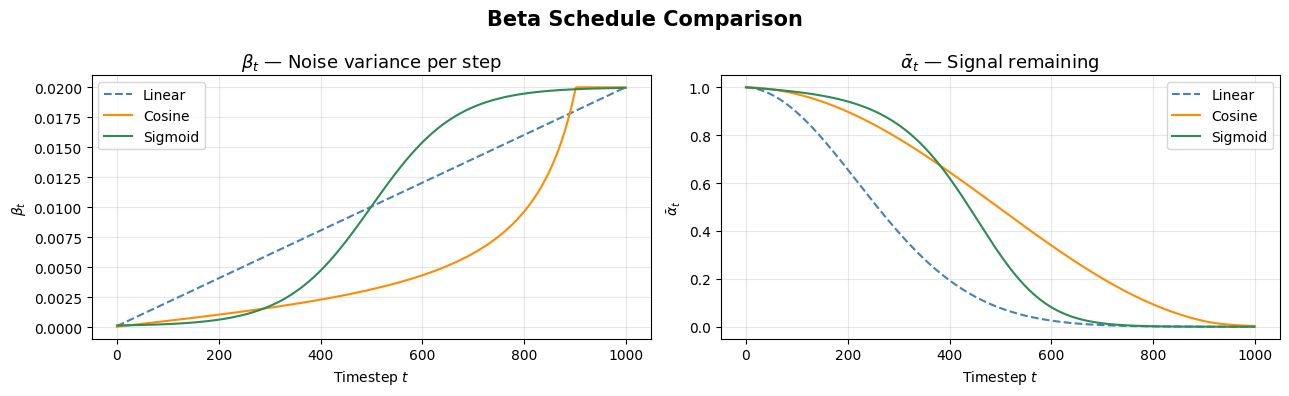


Key observation: the cosine schedule keeps more signal (higher ᾱ_t) for longer, 
which helps learning structure at small resolutions like 32×32.


In [9]:
timesteps = 1000

betas_linear  = linear_beta_schedule(0.0001, 0.02, timesteps)
betas_cosine  = cosine_beta_schedule(timesteps)
betas_sigmoid = sigmoid_beta_schedule(0.0001, 0.02, timesteps)

def get_alphas_cumprod(betas):
    return torch.cumprod(1. - betas, dim=0)

ac_lin = get_alphas_cumprod(betas_linear)
ac_cos = get_alphas_cumprod(betas_cosine)
ac_sig = get_alphas_cumprod(betas_sigmoid)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(betas_linear.numpy(),  label='Linear',  linestyle='--', color='steelblue')
axes[0].plot(betas_cosine.numpy(),  label='Cosine',               color='darkorange')
axes[0].plot(betas_sigmoid.numpy(), label='Sigmoid',              color='seagreen')
axes[0].set_title(r'$\beta_t$ — Noise variance per step', fontsize=13)
axes[0].set_xlabel('Timestep $t$'); axes[0].set_ylabel(r'$\beta_t$')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(ac_lin.numpy(),  label='Linear',  linestyle='--', color='steelblue')
axes[1].plot(ac_cos.numpy(),  label='Cosine',               color='darkorange')
axes[1].plot(ac_sig.numpy(),  label='Sigmoid',              color='seagreen')
axes[1].set_title(r'$\bar{\alpha}_t$ — Signal remaining', fontsize=13)
axes[1].set_xlabel('Timestep $t$'); axes[1].set_ylabel(r'$\bar{\alpha}_t$')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Beta Schedule Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('scheduler_comparison.png', dpi=120)
plt.show()
print("\nKey observation: the cosine schedule keeps more signal (higher ᾱ_t) for longer, \nwhich helps learning structure at small resolutions like 32×32.")

### 5.4 Forward Process Comparison Across Schedules

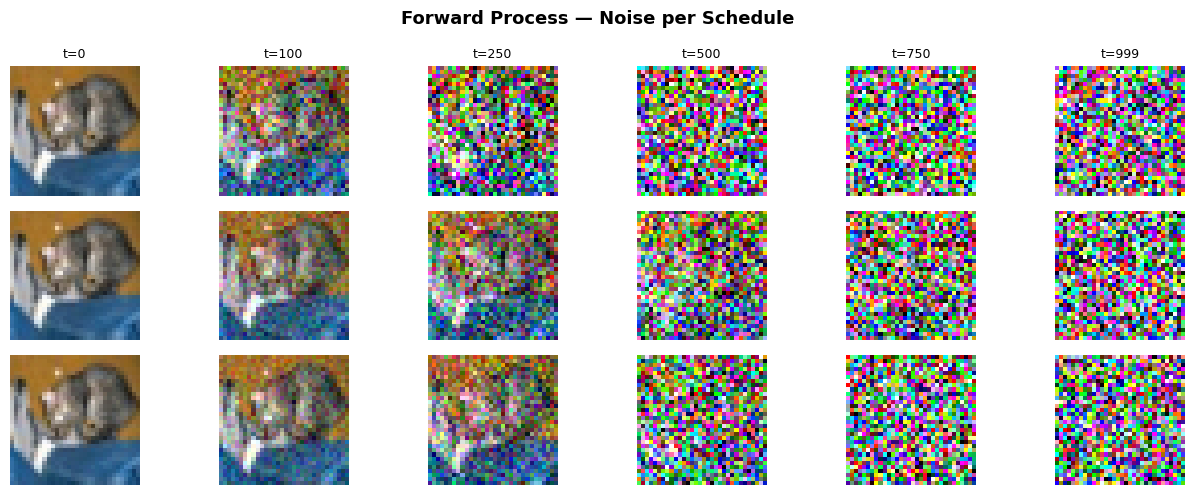

In [10]:
schedules = {
    'Linear':  MinimalDiffusor(1000, betas_linear),
    'Cosine':  MinimalDiffusor(1000, betas_cosine),
    'Sigmoid': MinimalDiffusor(1000, betas_sigmoid),
}

t_vals = [0, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(len(schedules), len(t_vals), figsize=(13, 5))

for row, (name, d) in enumerate(schedules.items()):
    for col, tv in enumerate(t_vals):
        t_tensor = torch.tensor([tv])
        noisy = q_sample(d, sample_img.unsqueeze(0), t_tensor)[0]
        img_show = ((noisy.permute(1, 2, 0) + 1) / 2).clamp(0, 1).numpy()
        axes[row, col].imshow(img_show)
        if row == 0: axes[row, col].set_title(f"t={tv}", fontsize=9)
        if col == 0: axes[row, col].set_ylabel(name, fontsize=10, fontweight='bold')
        axes[row, col].axis('off')

plt.suptitle('Forward Process — Noise per Schedule', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Exercise 2.4 — Classifier-Free Guidance

### 6.1 Motivation

An unconditional diffusion model generates random images — we have no control over what class is generated. **Classifier-Free Guidance (CFG)** by Ho & Salimans (2022) solves this by training a **single model** that can operate in both **conditional** and **unconditional** mode.

### 6.2 Training Strategy

- The UNet is extended with a **class embedding layer** $\mathbf{c} = \text{Emb}(y)$, injected via FiLM alongside the time embedding.
- With probability $p_{\text{uncond}}$ (typically 0.1–0.2), the class label is replaced with a learnable **null token** → the model learns unconditional generation too.
- This gives us a single model $\epsilon_\theta(\mathbf{x}_t, t, \mathbf{c})$ that can handle both modes.

### 6.3 Inference — Combining Both Predictions

During sampling, we run the model **twice** per step — once conditional, once unconditional — and blend:

$$\tilde{\epsilon}_\theta(\mathbf{x}_t, \mathbf{c}) = \underbrace{(1+w)}_{\text{conditional weight}} \epsilon_\theta(\mathbf{x}_t, t, \mathbf{c}) - \underbrace{w}_{\text{guidance scale}} \epsilon_\theta(\mathbf{x}_t, t)$$

- **$w = 0$**: Pure conditional generation (no guidance boost)
- **$w > 0$**: Push towards the class — higher $w$ → sharper/more class-specific images, but less diversity
- **$w < 0$**: Push away from the class

<div align="center">

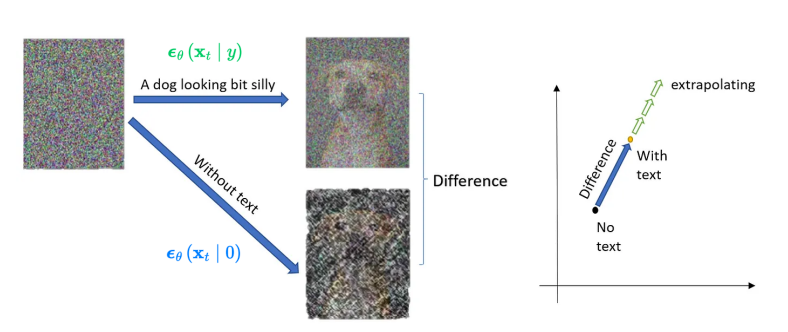

</div>

### 6.4 How It's Implemented

The `Unet.forward()` method already handles this:
- `classes=None` → use null token (unconditional)
- `classes=tensor` + `cond_drop_prob=0.1` → train with random label dropout
- `cond_drop_prob=0.0` at inference → always use the given label

The `Diffusion.p_sample()` applies the CFG formula when `guidance_scale > 0`.

In [11]:
# Quick demo: inspect the class embedding part of the model
model_demo = Unet(dim=32, channels=3, dim_mults=(1, 2, 4), num_classes=10).to(device)

total_params = sum(p.numel() for p in model_demo.parameters())
print(f"Total parameters: {total_params:,}")
print(f"Class embedding:  {model_demo.classes_emb}")
print(f"  (11 embeddings: 10 classes + 1 null token)")

# Show time embedding output shape
t_test = torch.randint(0, 100, (4,), device=device)
t_emb = model_demo.time_mlp(t_test)
print(f"\nTime embedding shape: {t_emb.shape}  (batch=4, dim={t_emb.shape[1]})")

# Show class embedding output shape
c_test = torch.tensor([0, 1, 5, 9], device=device)  # plane, car, dog, truck
c_emb = model_demo.classes_emb(c_test)
print(f"Class embedding shape: {c_emb.shape}  (same dim as time embedding — both injected via FiLM)")

Total parameters: 2,857,475
Class embedding:  Embedding(11, 128)
  (11 embeddings: 10 classes + 1 null token)

Time embedding shape: torch.Size([4, 128])  (batch=4, dim=128)
Class embedding shape: torch.Size([4, 128])  (same dim as time embedding — both injected via FiLM)


---
## 7. Training Loop

### 7.1 Configuration

In [12]:
# ── Hyperparameters ─────────────────────────────────────────────────────────
config = {
    "timesteps":       1000,
    "image_size":      32,
    "channels":        3,
    "epochs":          5,        # increase to 100-200 for a good model
    "batch_size":      64,
    "lr":              2e-4,
    "scheduler":       "cosine", # 'linear', 'cosine', or 'sigmoid'
    "guidance_scale":  2.0,
    "cond_drop_prob":  0.1,      # probability to replace label with null token
    "num_classes":     10,
    "loss_type":       "l2",
    "run_name":        "DDPM_cosine_cfg",
}

def get_scheduler_fn(name):
    if name == "linear":  return lambda x: linear_beta_schedule(0.0001, 0.02, x)
    elif name == "cosine": return cosine_beta_schedule
    elif name == "sigmoid": return lambda x: sigmoid_beta_schedule(0.0001, 0.02, x)
    else: raise ValueError(f"Unknown scheduler: {name}")

print("Configuration set.")
for k, v in config.items():
    print(f"  {k:20s}: {v}")

Configuration set.
  timesteps           : 1000
  image_size          : 32
  channels            : 3
  epochs              : 5
  batch_size          : 64
  lr                  : 0.0002
  scheduler           : cosine
  guidance_scale      : 2.0
  cond_drop_prob      : 0.1
  num_classes         : 10
  loss_type           : l2
  run_name            : DDPM_cosine_cfg


### 7.2 Data Loading

In [13]:
def scale_to_minus_one_one(t):
    return (t * 2) - 1

transform_train = Compose([
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    scale_to_minus_one_one,
])

reverse_transform = Compose([
    Lambda(lambda t: (t.clamp(-1, 1) + 1) / 2),
    Lambda(lambda t: t.permute(1, 2, 0)),
    Lambda(lambda t: t * 255.),
    Lambda(lambda t: t.numpy().astype(np.uint8)),
    ToPILImage(),
])

dataset   = datasets.CIFAR10('./data', download=True, train=True, transform=transform_train)
n_train   = int(len(dataset) * 0.9)
trainset, valset = torch.utils.data.random_split(dataset, [n_train, len(dataset) - n_train])
testset   = datasets.CIFAR10('./data', download=True, train=False, transform=transform_train)

# num_workers=0 avoids slow Windows multiprocessing overhead in notebooks
trainloader = DataLoader(trainset, batch_size=config["batch_size"], shuffle=True,  num_workers=0, pin_memory=True)
valloader   = DataLoader(valset,   batch_size=config["batch_size"], shuffle=False, num_workers=0, pin_memory=True)
testloader  = DataLoader(testset,  batch_size=config["batch_size"] // 2, shuffle=True)

print(f"Train: {len(trainset):,} | Val: {len(valset):,} | Test: {len(testset):,}")

Files already downloaded and verified
Files already downloaded and verified
Train: 45,000 | Val: 5,000 | Test: 10,000


### 7.3 Model, Optimizer & Diffusion

In [14]:
model = Unet(
    dim=config["image_size"],
    channels=config["channels"],
    dim_mults=(1, 2, 4),
    num_classes=config["num_classes"]
).to(device)

optimizer = AdamW(model.parameters(), lr=config["lr"])

diffusor = Diffusion(
    timesteps=config["timesteps"],
    get_noise_schedule=get_scheduler_fn(config["scheduler"]),
    img_size=config["image_size"],
    device=device
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,}")

Model parameters: 2,857,475


### 7.4 Training & Evaluation Functions

In [15]:
def train_epoch(model, loader, optimizer, diffusor, epoch):
    model.train()
    total_loss = 0.0
    pbar = tqdm(loader, desc=f"Epoch {epoch+1}", leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        t = torch.randint(0, config["timesteps"], (len(images),), device=device).long()
        loss = diffusor.p_losses(
            denoise_model=model,
            x_zero=images,
            t=t,
            loss_type=config["loss_type"],
            classes=labels,
            cond_drop_prob=config["cond_drop_prob"]
        )
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader)


def evaluate_epoch(model, loader, diffusor):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            t = torch.randint(0, config["timesteps"], (len(images),), device=device).long()
            loss = diffusor.p_losses(
                denoise_model=model,
                x_zero=images,
                t=t,
                loss_type=config["loss_type"],
                classes=labels,
                cond_drop_prob=0.0   # No dropout during evaluation
            )
            total_loss += loss.item()
    return total_loss / len(loader)


print("Training functions defined.")

Training functions defined.


### 7.5 Run Training

In [16]:
os.makedirs(f"./models/{config['run_name']}", exist_ok=True)
os.makedirs(f"./results/{config['run_name']}", exist_ok=True)

train_losses, val_losses = [], []
best_val_loss = float('inf')

for epoch in range(config["epochs"]):
    train_loss = train_epoch(model, trainloader, optimizer, diffusor, epoch)
    val_loss   = evaluate_epoch(model, valloader, diffusor)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1:3d}/{config['epochs']} — Train: {train_loss:.4f}  Val: {val_loss:.4f}")

    # Save best model
    torch.save(model.state_dict(), f"./models/{config['run_name']}/ckpt_last.pt")
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), f"./models/{config['run_name']}/ckpt_best.pt")
        print(f"  ★ New best model saved (val={val_loss:.4f})")

print("\nTraining complete!")

Epoch   1/5 — Train: 0.1314  Val: 0.0810
  ★ New best model saved (val=0.0810)


Epoch   2/5 — Train: 0.0790  Val: 0.0726
  ★ New best model saved (val=0.0726)


Epoch   3/5 — Train: 0.0717  Val: 0.0713
  ★ New best model saved (val=0.0713)


Epoch   4/5 — Train: 0.0674  Val: 0.0707
  ★ New best model saved (val=0.0707)


Epoch   5/5 — Train: 0.0659  Val: 0.0664
  ★ New best model saved (val=0.0664)

Training complete!


---
## 8. Visualization & Results

### 8.1 Loss Curves

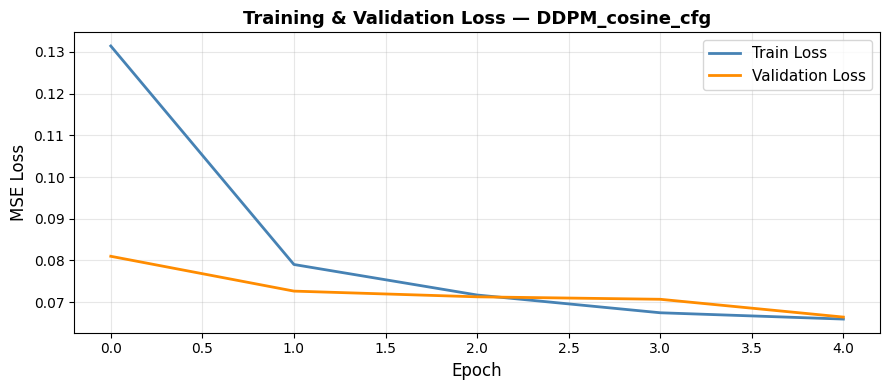

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(train_losses, label='Train Loss',      color='steelblue',   linewidth=2)
ax.plot(val_losses,   label='Validation Loss', color='darkorange',  linewidth=2)
ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('MSE Loss', fontsize=12)
ax.set_title(f'Training & Validation Loss — {config["run_name"]}', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"./results/{config['run_name']}/loss_curve.png", dpi=120)
plt.show()

### 8.2 Generated Image Grid (with CFG)

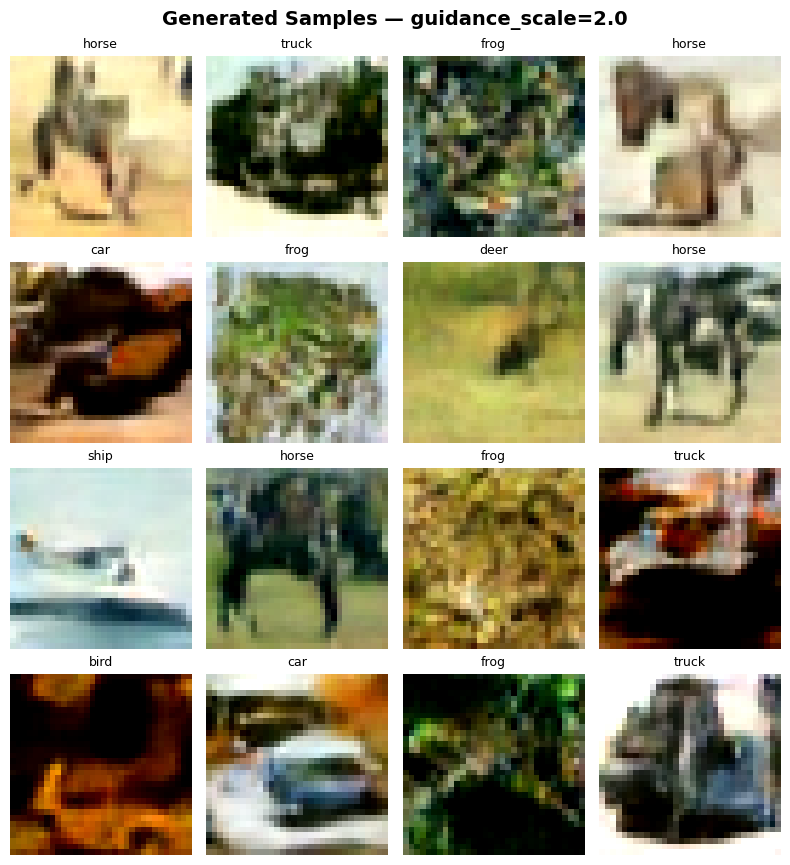

In [18]:
@torch.no_grad()
def plot_labeled_grid(model, diffusor, n_images=16, guidance_scale=2.0):
    model.eval()
    rows = int(np.sqrt(n_images))
    cols = int(np.ceil(n_images / rows))
    labels = torch.randint(0, 10, (n_images,), device=device)

    images = diffusor.sample(
        model=model, image_size=diffusor.img_size,
        batch_size=n_images, channels=3,
        classes=labels, guidance_scale=guidance_scale
    )

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.2))
    axes = axes.flatten()
    fig.suptitle(f'Generated Samples — guidance_scale={guidance_scale}', fontsize=14, fontweight='bold')

    for i in range(n_images):
        img = ((images[i].cpu().permute(1, 2, 0) + 1) * 0.5).clamp(0, 1).numpy()
        axes[i].imshow(img)
        axes[i].set_title(CIFAR10_CLASSES[labels[i].item()], fontsize=9)
        axes[i].axis('off')
    for i in range(n_images, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig(f"./results/{config['run_name']}/generated_grid_w{guidance_scale}.png", dpi=120)
    plt.show()


plot_labeled_grid(model, diffusor, n_images=16, guidance_scale=config["guidance_scale"])

### 8.3 Effect of Guidance Scale $w$

Higher guidance scale → more class-faithful images but reduced diversity. Let's compare:

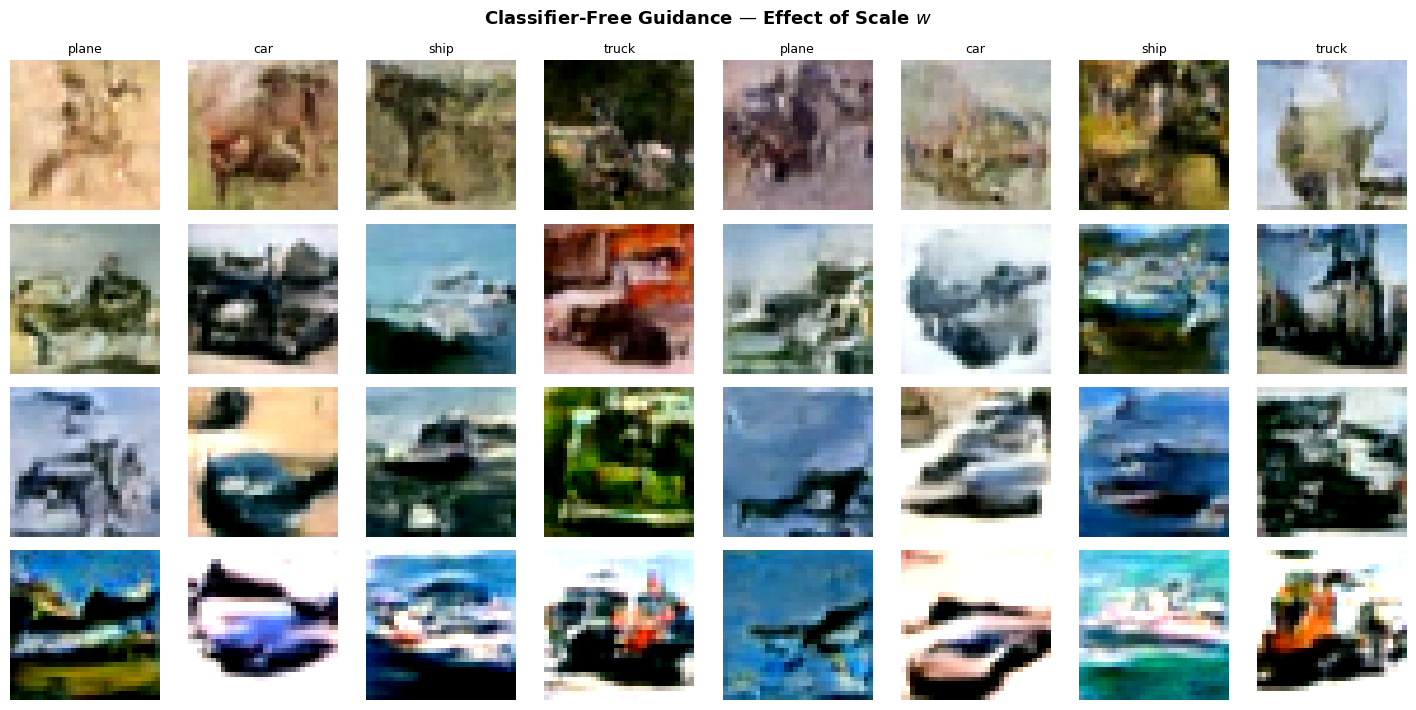

In [19]:
@torch.no_grad()
def compare_guidance_scales(model, diffusor, scales=(0.0, 1.0, 2.0, 5.0), n_per_class=2):
    model.eval()
    selected_classes = [0, 1, 8, 9]  # plane, car, ship, truck
    n_imgs = len(selected_classes) * n_per_class
    labels = torch.tensor(selected_classes * n_per_class, device=device).long()

    fig, axes = plt.subplots(len(scales), n_imgs, figsize=(n_imgs * 1.8, len(scales) * 1.8))

    for row, w in enumerate(scales):
        imgs = diffusor.sample(model=model, image_size=diffusor.img_size,
                               batch_size=n_imgs, channels=3,
                               classes=labels, guidance_scale=w)
        for col in range(n_imgs):
            img = ((imgs[col].cpu().permute(1, 2, 0) + 1) * 0.5).clamp(0, 1).numpy()
            axes[row, col].imshow(img)
            if row == 0:
                axes[row, col].set_title(CIFAR10_CLASSES[labels[col].item()], fontsize=9)
            axes[row, col].axis('off')
        axes[row, 0].set_ylabel(f'w={w}', fontsize=10, fontweight='bold', rotation=0, labelpad=40, va='center')

    plt.suptitle('Classifier-Free Guidance — Effect of Scale $w$', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


compare_guidance_scales(model, diffusor)

### 8.4 Visualize the Denoising Process

Let's watch a sample being generated step by step:

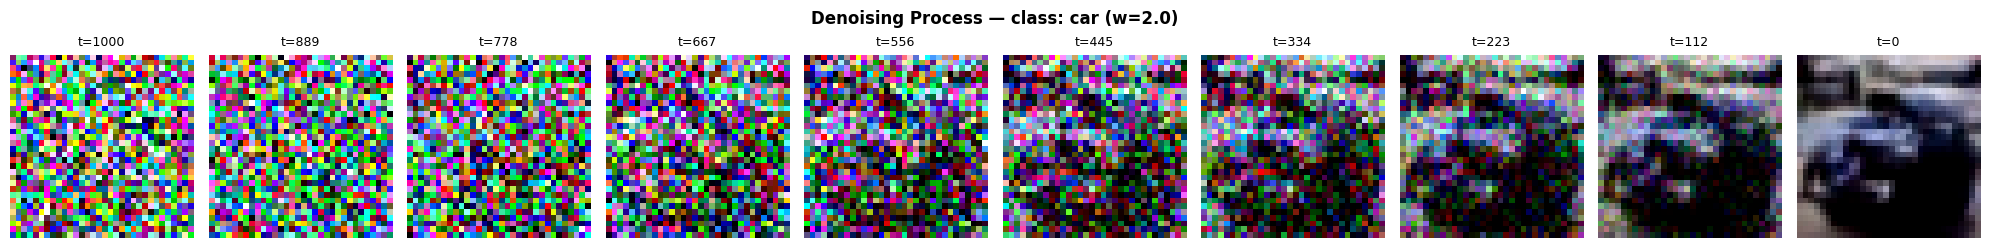

In [20]:
@torch.no_grad()
def plot_denoising_steps(model, diffusor, class_idx=0, guidance_scale=2.0, n_steps_shown=10):
    model.eval()
    label = torch.tensor([class_idx], device=device)

    x_seq = diffusor.sample(
        model=model, image_size=diffusor.img_size,
        batch_size=1, channels=3,
        return_all_timesteps=True,
        classes=label, guidance_scale=guidance_scale
    )

    total_steps = x_seq.shape[0]
    step_indices = np.linspace(0, total_steps - 1, n_steps_shown, dtype=int)

    fig, axes = plt.subplots(1, n_steps_shown, figsize=(n_steps_shown * 2, 2.5))
    for ax, idx in zip(axes, step_indices):
        t_shown = total_steps - 1 - idx  # t goes from T down to 0
        img = x_seq[idx, 0].cpu()
        img_show = ((img.permute(1, 2, 0) + 1) / 2).clamp(0, 1).numpy()
        ax.imshow(img_show)
        ax.set_title(f"t={t_shown}", fontsize=9)
        ax.axis('off')

    plt.suptitle(f'Denoising Process — class: {CIFAR10_CLASSES[class_idx]} (w={guidance_scale})',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


plot_denoising_steps(model, diffusor, class_idx=1, guidance_scale=2.0)

### 8.5 Summary

| Component | What we implemented |
|-----------|--------------------|
| **Forward process** `q_sample` | Closed-form $x_t = \sqrt{\bar\alpha_t}x_0 + \sqrt{1-\bar\alpha_t}\epsilon$ |
| **Reverse step** `p_sample` | Eq. 8: predict noise, subtract, add stochastic term |
| **Loss** `p_losses` | L1/L2 between true and predicted noise |
| **Schedulers** | Linear, cosine (Nichol & Dhariwal), sigmoid |
| **CFG** | Null-token dropout during training; guided blending at inference |

**Tips for better results:**
- Train for 100–200 epochs for visually plausible CIFAR-10 images.
- The **cosine** schedule consistently outperforms linear at 32×32 resolution.
- Guidance scale $w \in [1.5, 3.0]$ is a good practical range — too high leads to artifacts.
- Consider FID or IS scores for quantitative evaluation.